In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [98]:
df = pd.read_csv('ncr_ride_bookings.csv')
df.head()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,...,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,...,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,...,NaN,NaN,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,...,NaN,NaN,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI


In [99]:
df["DateTime"] = pd.to_datetime(df["Date"].astype(
    str) + " " + df["Time"].astype(str), errors="coerce")

df = df.dropna(subset=["DateTime", "Booking Value"])
df["Booking Value"] = pd.to_numeric(df["Booking Value"], errors="coerce")
df["Ride Distance"] = pd.to_numeric(df["Ride Distance"], errors="coerce")

for col in ["Driver Ratings", "Customer Rating"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(-1.0)
    else:
        df[col] = -1.0

plain_df = df.copy()
multi_df = df.copy().set_index(["Booking Status", "Driver Ratings", "Customer Rating", "Booking Value"])

cat_cols = ["Booking Status", "Vehicle Type",
            "Pickup Location", "Drop Location", "Payment Method"]
for c in cat_cols:
    if c in plain_df.columns:
        plain_df[c] = plain_df[c].astype("category")

multi_df = multi_df.sort_index()

In [100]:
multi_df.head()

Date  \
Booking Status Driver Ratings Customer Rating Booking Value               
Completed      3.0            3.0             246.0          2024-08-19   
                                              657.0          2024-01-07   
                                              825.0          2024-06-24   
                                              885.0          2024-08-14   
                              3.1             80.0           2024-07-19   

                                                                 Time  \
Booking Status Driver Ratings Customer Rating Booking Value             
Completed      3.0            3.0             246.0          21:46:44   
                                              657.0          10:54:59   
                                              825.0          18:53:42   
                                              885.0          10:58:47   
                              3.1             80.0           12:22:37   

                                                               Booking ID  \
Booking Status Driver Ratings Customer Rating Booking Value                 
Completed      3.0            3.0             246.0          "CNR9567795"   
                                              657.0          "CNR6113524"   
                                              825.0          "CNR6547349"   
                                              885.0          "CNR7362987"   
                              3.1             80.0           "CNR6449508"   

                                                              Customer ID  \
Booking Status Driver Ratings Customer Rating Booking Value                 
Completed      3.0            3.0             246.0          "CID1363592"   
                                              657.0          "CID1859273"   
                                              825.0          "CID9061792"   
                                              885.0          "CID5614461"   
                              3.1             80.0           "CID8768366"   

                                                              Vehicle Type  \
Booking Status Driver Ratings Customer Rating Booking Value                  
Completed      3.0            3.0             246.0          Premier Sedan   
                                              657.0          Premier Sedan   
                                              825.0                Go Mini   
                                              885.0                Go Mini   
                              3.1             80.0           Premier Sedan   

                                                                 Pickup Location  \
Booking Status Driver Ratings Customer Rating Booking Value                        
Completed      3.0            3.0             246.0                    Pitampura   
                                              657.0                        Saket   
                                              825.0                  Gwal Pahari   
                                              885.0          Sadar Bazar Gurgaon   
                              3.1             80.0              Anand Vihar ISBT   

                                                                   Drop Location  \
Booking Status Driver Ratings Customer Rating Booking Value                        
Completed      3.0            3.0             246.0                  IGI Airport   
                                              657.0                   Karol Bagh   
                                              825.0          Raj Nagar Extension   
                                              885.0                      Jhilmil   
                              3.1             80.0                     Sultanpur   

                                                             Avg VTAT  \
Booking Status Driver Ratings Customer Rating Booking Value             
Completed      3.0            3.0             246.0               8.4   
     

In [101]:
np.random.seed(2025)
unique_pickups = df["Pickup Location"].dropna().unique()
sample_pickup = np.random.choice(unique_pickups)
possible_drops = df.loc[df["Pickup Location"] ==
                        sample_pickup, "Drop Location"].dropna().unique()
sample_drop = np.random.choice(possible_drops) if len(
    possible_drops) else np.random.choice(df["Drop Location"].dropna().unique())

date_low = pd.to_datetime("2024-05-01")
date_high = pd.to_datetime("2024-09-01")
value_threshold = 300.0

vehicle_vals = plain_df["Vehicle Type"].dropna().unique()
vehicle_list = np.random.choice(vehicle_vals, size=min(
    3, len(vehicle_vals)), replace=False).tolist() if len(vehicle_vals) else []
payment_vals = plain_df["Payment Method"].dropna().unique()
payment_list = np.random.choice(payment_vals, size=min(
    2, len(payment_vals)), replace=False).tolist() if len(payment_vals) else []

top_n = 30
REPEATS = 10

print("Тестовая пара:", sample_pickup, "->", sample_drop)
print("Vehicle list:", vehicle_list)
print("Payment list:", payment_list)
print("Порог Booking Value:", value_threshold)
print("Повторы:", REPEATS)

Тестовая пара: Maidan Garhi -> South Extension
Vehicle list: ['Auto', 'Premier Sedan', 'Uber XL']
Payment list: ['Uber Wallet', 'Credit Card']
Порог Booking Value: 300.0
Повторы: 10


In [110]:
def query_Q1_plain(df_local):
    m = (
        (df_local["Pickup Location"] == sample_pickup) &
        (df_local["Drop Location"] == sample_drop) &
        (df_local["Booking Status"] == "Completed") &
        (df_local["DateTime"] >= date_low) &
        (df_local["DateTime"] <= date_high) &
        (df_local["Booking Value"] > value_threshold)
    )
    return df_local.loc[m]


def query_Q1_multi(df_local):
    try:
        s = df_local.xs((sample_pickup, sample_drop))
    except KeyError:
        return df_local.iloc[0:0]
    if isinstance(s, pd.Series):
        s = s.to_frame().T
    return s.loc[
        (s["Booking Status"] == "Completed") &
        (s["DateTime"] >= date_low) &
        (s["DateTime"] <= date_high) &
        (s["Booking Value"] > value_threshold)
    ]


def query_Q2_plain(df_local):
    if len(vehicle_list) == 0 or len(payment_list) == 0:
        return df_local.iloc[0:0]
    m = df_local["Vehicle Type"].isin(
        vehicle_list) & df_local["Payment Method"].isin(payment_list)
    res = df_local.loc[m].groupby(
        ["Pickup Location", "Drop Location"], as_index=False)["Booking Value"].mean()
    return res.sort_values("Booking Value", ascending=False).head(top_n)


def query_Q2_multi(df_local):
    if len(vehicle_list) == 0 or len(payment_list) == 0:
        return df_local.iloc[0:0]
    m = df_local["Vehicle Type"].isin(
        vehicle_list) & df_local["Payment Method"].isin(payment_list)
    res = df_local.loc[m].groupby(["Pickup Location", "Drop Location"], as_index=False)[
        "Booking Value"].mean()
    return res.sort_values("Booking Value", ascending=False).head(top_n)


def query_Q3_plain(df_local):
    q = df_local.query(
        "`Booking Status` == 'Completed' and `Driver Ratings` >= 4 and `Customer Rating` >= 4 and `Booking Value` > @value_threshold")
    return q.sort_values("Booking Value", ascending=False).head(top_n)


def query_Q3_multi(df_local):
    q = df_local.query(
        "`Booking Status` == 'Completed' and `Driver Ratings` >= 4 and `Customer Rating` >= 4 and `Booking Value` > @value_threshold")
    return q.sort_values("Booking Value", ascending=False).head(top_n)


def measure_time(func, df_local, repeats=REPEATS):
    times = []
    try:
        _ = func(df_local)
    except Exception as e:
        return float("nan"), [str(e)]
    for _ in range(repeats):
        t0 = time.perf_counter()
        try:
            _ = func(df_local)
        except Exception as e:
            return float("nan"), [str(e)]
        t1 = time.perf_counter()
        times.append(t1 - t0)
    return float(np.median(times)), float(np.average(times)), times

In [111]:
q_funcs = [
    ("Q3", query_Q3_plain, query_Q3_multi),
]
results = []
for name, f_plain, f_multi in q_funcs:
    t_plain, avg_plain, all_plain = measure_time(f_plain, plain_df)
    t_multi, avg_multi, all_multi = measure_time(f_multi, multi_df)
    results.append({
        "query": name,
        "plain_median_s": t_plain,
        "plain_avg_s": avg_plain,
        "multi_median_s": t_multi,
        "multi_avg_s": avg_multi,
        "plain_all": all_plain,
        "multi_all": all_multi
    })

res_df = pd.DataFrame(results).set_index("query")

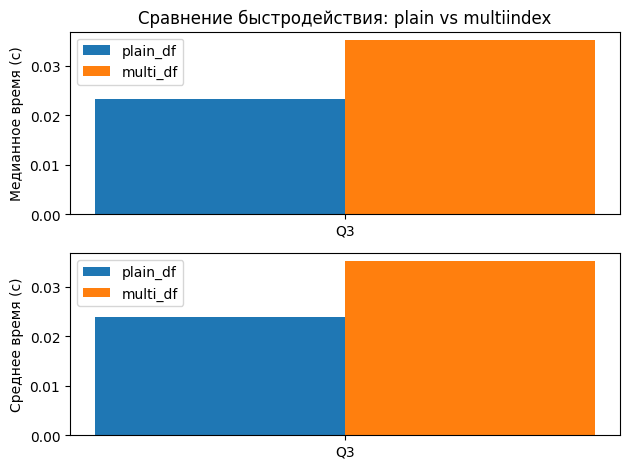

In [112]:
fig, (ax1, ax2) = plt.subplots(2, 1)
x = np.arange(len(res_df.index))
width = 0.35

ax1.bar(x - width/2, res_df["plain_median_s"], width, label="plain_df")
ax1.bar(x + width/2, res_df["multi_median_s"], width, label="multi_df")
ax1.set_xticks(x)
ax1.set_xticklabels(res_df.index)
ax1.set_ylabel("Медианное время (с)")
ax1.set_title("Сравнение быстродействия: plain vs multiindex")
ax1.legend()


ax2.bar(x - width/2, res_df["plain_avg_s"], width, label="plain_df")
ax2.bar(x + width/2, res_df["multi_avg_s"], width, label="multi_df")
ax2.set_xticks(x)
ax2.set_xticklabels(res_df.index)
ax2.set_ylabel("Среднее время (с)")
ax2.legend()

plt.tight_layout()
plt.show()

In [113]:
res_df.to_csv('search_battle.csv')